APLICACIÓN DE ANOVA y MI:

Uso de Mutual Information (MI) para todos los casos posibles de análisis de una variable continua versus una categórica objetivo, y aplicación de ANOVA en aquellos casos en que se cumplan las condiciones necesarias de su uso.
Realice gráficos y conclusiones significativas para todos los casos analizados.


---



BIBLIOTECAS

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Carga de archivos
x = np.load("/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°2 ANOVA/X_iris.npy")
y = np.load("/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°2 ANOVA/y_iris.npy")
y_clases = np.load("/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°2 ANOVA/y_clases.npy", allow_pickle=True)
df_original = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Analisis de la informacion/Ejercicio N°2 ANOVA/iris.tab", sep="\t")

In [ ]:
# Creo df con nombres de columnas
feature_names = df_original.columns[:-1]
df = pd.DataFrame(x, columns=feature_names)

# Agregar la columna 'y' con nombres de clase
df['y'] = [y_clases[i] for i in y]

# Mostrar las primeras filas
df

,sepal length,sepal width,petal length,petal width,y
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica


En este dataset, vamos a encontrar cuatro variables predictoras continuas x = {'sepal length', 'sepal width', 'petal length', 'petal width'}  y una variable objetivo target 'y' que es categórica.
Las variables continuas reflejan las características específicas para cada flor (largo y ancho del sépalo, largo y ancho del pétalo), y en el target se encuentran representadas los distintos tipos de flores.


Ahora se empieza aplicando el método describe() para ver como está distribuidos los datos.

In [ ]:
df.describe()

,sepal length,sepal width,petal length,petal width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Ahora vamos a ver las distintas clases (tipos de flores) que asume el target 'y'.

In [ ]:
df['y'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

Como vemos, el target se divide en tres tipos de flores: Iris-setosa, Iris-versicolor e Iris-virginica. Nuestro objetivo es determinar si existe relación o no entre las variables continuas xi frente a la variable categórica y, es decir, la relación entre las distintas caracteristicas de las flores y su tipo.

Para ello, vamos a usar dos métodos ya trabajados anteriormente: unos es el 'Mutual Information' (información mutua) donde se aplica en cada una de las variables continuas respecto a la variable objetivo, sin la necesidad de que se cumplan ciertas condiciones.

Otro de los métodos es ANOVA (Análisis de la Varianza), el cual se utiliza siempre y cuando se cumplan sus condiciones para cada uno de los subgrupos de xi.

A continuación, se aplicará como primer medida el método de Información Mutua, ya que es aplicable para todas las variables continuas en este caso.

**APLICACIÓN DE MUTUAL INFORMATION (clasificación)**

Se aplicará sobre las variables
*sepal length, sepal width, petal length, petal width,* el cálculo de Mutual Information en cada una respecto de la variable objetivo. Luego se muestra si existe o no relación, donde sabemos que si MI > 0 indica que SI hay relación y MI = 0 que NO hay relación.



In [ ]:
from sklearn.feature_selection import mutual_info_classif



variables_continuas = ['sepal length', 'sepal width', 'petal length', 'petal width']

for var in variables_continuas:
    print(f"\n - Análisis de MI para la variable: {var}")

    x = np.array(df[var]).reshape(-1, 1)  # Darle formato de matriz columna
    MI = mutual_info_classif(x, df['y'], discrete_features='auto', n_neighbors=3, copy=True, random_state=123)

    if MI[0] > 0:
        print(f"MI > 0 : {MI} → Existe relación entre {var} e y")
    else:
        print(f"MI = 0 : {MI} → NO existe relación entre {var} e y")


 - Análisis de MI para la variable: sepal length
MI > 0 : [0.51285004] → Existe relación entre sepal length e y

 - Análisis de MI para la variable: sepal width
MI > 0 : [0.2121944] → Existe relación entre sepal width e y

 - Análisis de MI para la variable: petal length
MI > 0 : [0.98972858] → Existe relación entre petal length e y

 - Análisis de MI para la variable: petal width
MI > 0 : [0.98273257] → Existe relación entre petal width e y


Como sabemos, este método casi siempre nos va mostrar que habria relación entre las variables, y sólo dependerá del análisis que nosotros realicemos para descartar o no si existe.
Viendo los resultados vemos que todas presentan cierta relación con y, pero para el largo y ancho del petalo hay una fuerte relación ya que tenemos un MI = 0.98, en relación a las demás variables.

Otro aspecto a tener en cuenta es que, la variable 'sepal width' referida a el ancho del sépalo, es la que tiene un valor de MI mucho menor que el resto (MI = 0.21). Con lo cual, diriamos que podría no tener relación con los tipos de flores al no ser tan representativa de y.

Por ello, para estar más seguros se aplica, si es posible, el método ANOVA para obtener más conclusiones al respecto.

**APLICACIÓN DE ANOVA**

Como dijimos anteriormente, aplicaremos el método de Análisis de las Varianzas para realizar un análisis más completo de las variables.

Recordemos que para usar ANOVA primero debemos verificar que se cumplan las siguientes condiciones:


1.   La variable  xi  sea continua
2.   La variable  y  sea categórica con por lo menos 3 categorías.
3.   Cada uno de los subconjuntos de xi debe tener una distribución normal.
4.   Homogeneidad de las Varianzas: las varianzas dentro de cada uno de los subconj de xi deben ser iguales en lo mejor de los casos, o sino que el máximo de las varianzas de un subgrupo de xi no superen en 2 ó 4  la varianza mínima de otro subgrupo de xi.

Aclaración: para todas las variables xi, se van a cumplir las primeras dos condiciones de ANOVA, ya que todas las xi son continuas y la variable objetivo tiene al menos 3 categorías ('Iris-setosa', 'Iris-versicolor', 'Iris-virginica'). Por lo tanto procedemos a verificar las condiciones de normalidad y homogeneidad de las varianzas.

*Variable sepal length*

Condición de normalidad

In [ ]:
seplength_set = df['sepal length'][df.y=='Iris-setosa']
dfseplength_set=pd.DataFrame(seplength_set)
dfseplength_set.columns=['sepal length - setosa']

seplength_ver = df['sepal length'][df.y=='Iris-versicolor']
dfseplength_ver=pd.DataFrame(seplength_ver)
dfseplength_ver.columns=['sepal length - versicolor']

seplength_vir = df['sepal length'][df.y=='Iris-virginica']
dfseplength_vir=pd.DataFrame(seplength_vir)
dfseplength_vir.columns=['sepal length - virginica']


<Axes: title={'center': 'Figura 3'}, ylabel='Density'>

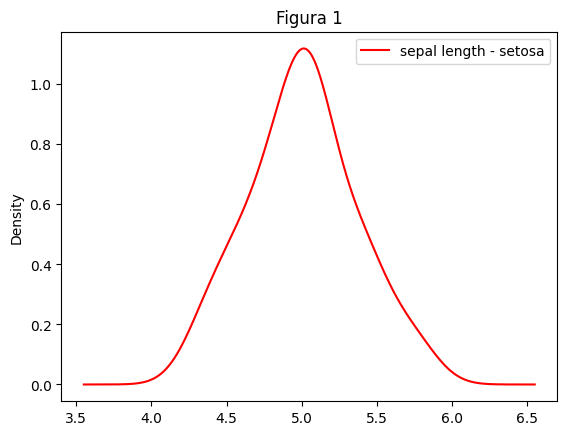

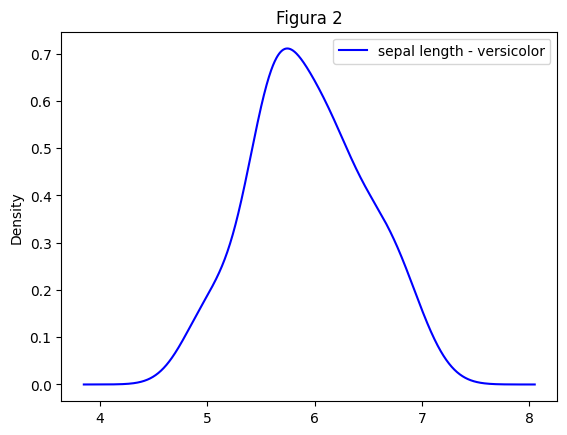

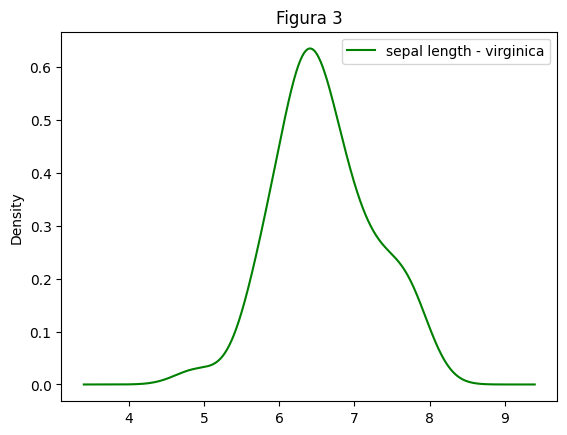

In [ ]:
dfseplength_set.plot.kde(color='red', title='Figura 1')
dfseplength_ver.plot.kde(color='blue', title='Figura 2')
dfseplength_vir.plot.kde(color='green', title='Figura 3')

Si las visualizamos todas juntas:

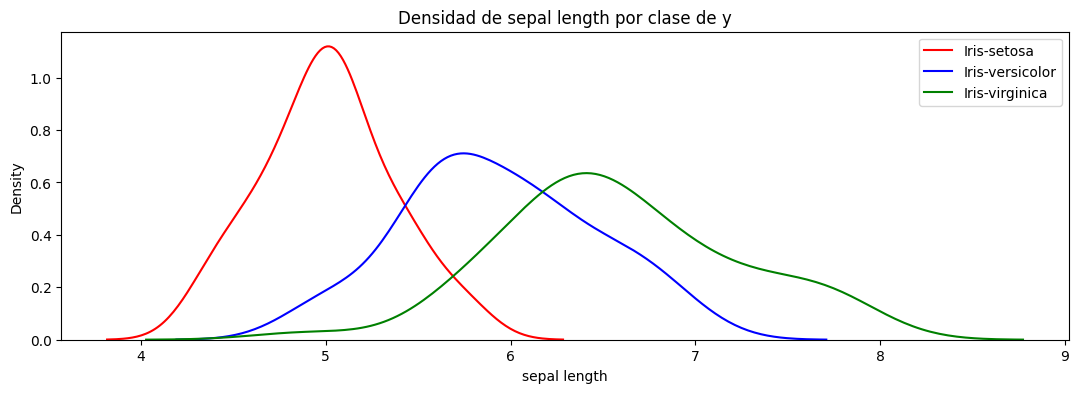

In [ ]:
plt.figure(figsize=(13,4))
sns.kdeplot(seplength_set, color='red', label='Iris-setosa')
sns.kdeplot(seplength_ver, color='blue', label='Iris-versicolor')
sns.kdeplot(seplength_vir, color='green', label='Iris-virginica')
plt.title('Densidad de sepal length por clase de y')
plt.legend()
plt.xlabel('sepal length')
plt.show()

Si bien en los gráficos individuales podemos ver que presentan una distribución normal por las formas de las campanas de Gauss, pero cuando las combinamos para ver todas juntas, estas se superponen y las varianzas internas se ven bastantes diferente entre ellas.

No estamos del todo seguro que exista relación entre sepal length e y, ya que nos costaría determinar los valores de sepal length para cada unos de los subgrupos en relación a y. Sin embargo, visualmente podríamos decir que se puede aplicar ANOVA. Por ello calculamos el estimador para tener más pruebas.

In [ ]:
# NORMALIDAD seplength_set
from scipy.stats import shapiro

alpha = 0.05                           # Nivel de significancia
W, p = shapiro(seplength_set)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.978
p= 0.46
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD seplength_ver

alpha = 0.05                           # Nivel de significancia
W, p = shapiro(seplength_ver)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.978
p= 0.465
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD seplength_vir

alpha = 0.05                           # Nivel de significancia
W, p = shapiro(seplength_vir)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.971
p= 0.258
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


De los valores obtenidos para los tres subconjuntos de sepal length (Iris setosa, Iris versicolor, Iris virginica) vemos que todos cumplirian con la condición de normalidad por los valores de probabilidad que son medianamente altos. Además si contamos  el nivel de significancia del 5%, podriamos asumir que no es posible rechazar la hipótesis de que es Gaussiana.

Ahora calculamos las varianzas para ver la otra condición de ANOVA:

Condición de homogeneidad de varianzas

In [ ]:
# HOMOGENEIDAD DE LAS VARIANZAS
var_seplength_set=np.var(seplength_set)
var_seplength_ver=np.var(seplength_ver)
var_seplength_vir=np.var(seplength_vir)

max_var=np.max([var_seplength_set,var_seplength_ver,var_seplength_vir])     # Máximo de las varianzas de los subgrupos
min_var=np.min([var_seplength_set,var_seplength_ver,var_seplength_vir])     # Mínimo de las varianzas de los subgrupos

ratio_var_sepal_length=max_var/min_var                  # Cálculo de ratio
print('ratio_var_x1= ', ratio_var_sepal_length)

ratio_var_x1=  3.2542964731860926


Bueno como vemos el ratio nos dio dentro de los márgenes aceptables, es decir, no mayor a 2 (o en casos extremos no mayor a 4). Aunque nos dio un valor cerca de 4, lo cual coincidide con lo que vemos del gráfico del ancho de las campanas.

Al cumplirse todos los requisitos, se procede aplicar ANOVA:

PLANTEO DE HIPÓTESIS

Lo que se busca demostrar en este problema es si hay alguna relación o no entre las variables xi e y. Para ello planteamos las siguientes hipótesis:

H1 : "Existe relación entre la variable sepal length  e y" (hipótesis alternativa)

Ho : "No existe relación entre la variable sepal length  e y" (hipótesis nula)

In [ ]:
# ANOVA
from sklearn.feature_selection import f_classif

alfa=0.05

X_sepal_length=np.array(df['sepal length']).reshape(-1, 1)

f,p = f_classif(X_sepal_length,df['y'])                      # f es el estimador y p la probabilidad de que se cumpla HO.

if p<=alfa:
    print("p: ",p)
    print('f:',f)
    print("Se rechaza la Hipótesis Nula, por lo tanto existe relación entre las variables")
else:
    print("p: ",p)
    print('f:',f)
    print("No es posible rechazar la Hipótesis Nula, asumiremos que NO existe relación entre las variables")


p:  [1.6684847e-31]
f: [119.2663634]
Se rechaza la Hipótesis Nula, por lo tanto existe relación entre las variables


Como vemos se obtiene una probabilidad muy baja, de que se cumpla la hipótesis nula. Con lo cual, al tener un nivel de significancia del 0.05, decidimos rechazar H0. Por ello, asumiremos que SI existe relación entre la variable sepal length e y (según el test de ANOVA).

*Variable sepal width*

Condición de normalidad

In [ ]:
sepwidth_set = df['sepal width'][df.y=='Iris-setosa']
dfsepwidth_set=pd.DataFrame(sepwidth_set)
dfsepwidth_set.columns=['sepal width - setosa']

sepwidth_ver = df['sepal width'][df.y=='Iris-versicolor']
dfsepwidth_ver=pd.DataFrame(sepwidth_ver)
dfsepwidth_ver.columns=['sepal width - versicolor']

sepwidth_vir = df['sepal width'][df.y=='Iris-virginica']
dfsepwidth_vir=pd.DataFrame(sepwidth_vir)
dfsepwidth_vir.columns=['sepal width - virginica']


<Axes: title={'center': 'Figura 6'}, ylabel='Density'>

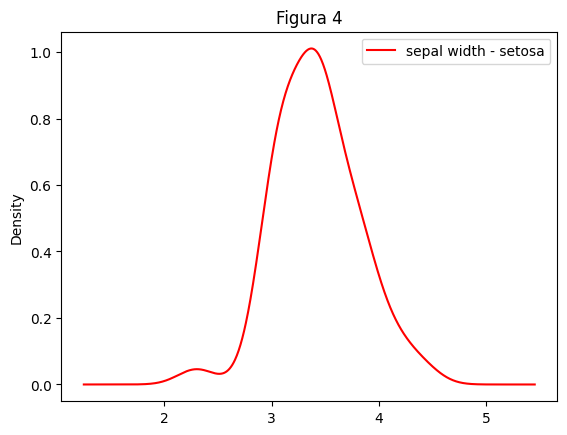

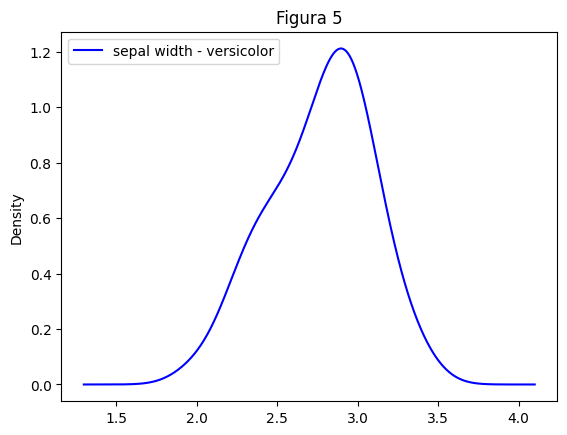

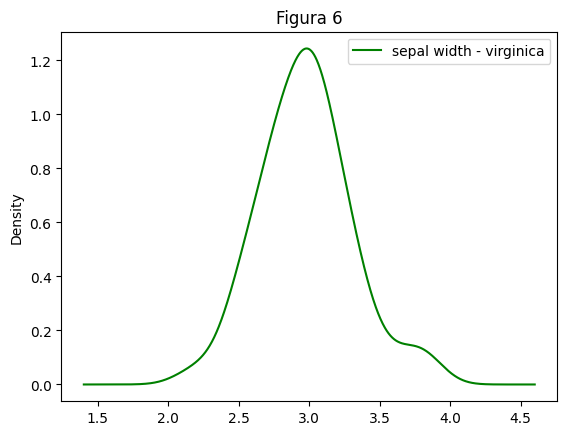

In [ ]:
dfsepwidth_set.plot.kde(color='red', title='Figura 4')
dfsepwidth_ver.plot.kde(color='blue', title='Figura 5')
dfsepwidth_vir.plot.kde(color='green', title='Figura 6')

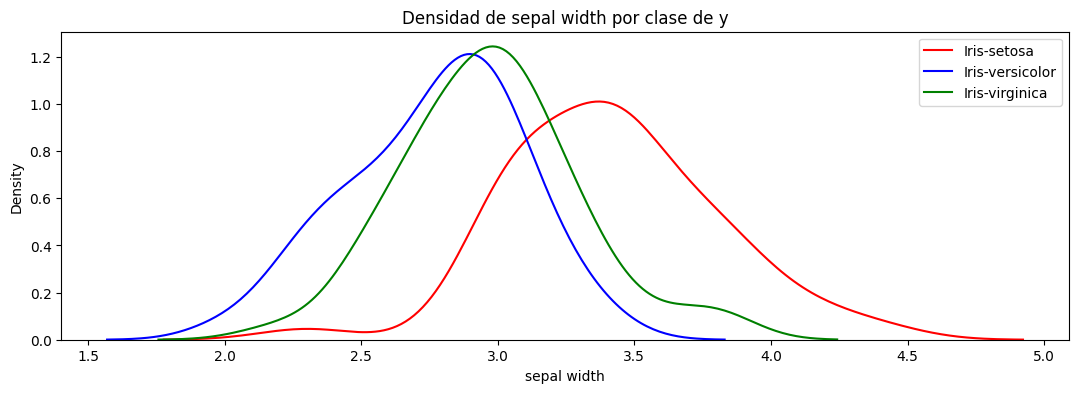

In [ ]:
plt.figure(figsize=(13,4))
sns.kdeplot(sepwidth_set, color='red', label='Iris-setosa')
sns.kdeplot(sepwidth_ver, color='blue', label='Iris-versicolor')
sns.kdeplot(sepwidth_vir, color='green', label='Iris-virginica')
plt.title('Densidad de sepal width por clase de y')
plt.legend()
plt.xlabel('sepal width')
plt.show()

Estos gráficos, tanto los individuales como cuando las combinamos para ver todas las campanas juntas, son similares al caso anterior. Parecen tener distribución normal, pero para estar seguros aplicamos shapiro.

In [ ]:
# NORMALIDAD sepwidth_set


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(sepwidth_set)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.969
p= 0.205
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD sepwidth_ver


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(sepwidth_ver)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.974
p= 0.338
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD sepwidth_vir


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(sepwidth_vir)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.967
p= 0.181
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


De los resultados para los tres subconjuntos de sepal width (Iris setosa, Iris versicolor, Iris virginica) vemos que todos cumplirian con la condición de normalidad por los valores de probabilidad que están por encima del nivel de significancia. De esta manera, podriamos asumir que no es posible rechazar la H0 de que es Gaussiana.

Ahora calculamos las varianzas para ver la otra condición de ANOVA:

Condición de homogeneidad:

In [ ]:
# HOMOGENEIDAD DE LAS VARIANZAS
var_sepwidth_set=np.var(sepwidth_set)
var_sepwidth_ver=np.var(sepwidth_ver)
var_sepwidth_vir=np.var(sepwidth_vir)

max_var=np.max([var_sepwidth_set,var_sepwidth_ver,var_sepwidth_vir])     # Máximo de las varianzas de los subgrupos
min_var=np.min([var_sepwidth_set,var_sepwidth_ver,var_sepwidth_vir])     # Mínimo de las varianzas de los subgrupos

ratio_var_sepal_width=max_var/min_var                  # Cálculo de ratio
print('ratio_var_x1= ', ratio_var_sepal_width)

ratio_var_x1=  1.4743624388241765


Bueno vemos que el ratio nos dio dentro de los márgenes aceptables, no mayor a 2 (o en casos extremos no mayor a 4).

Al cumplirse todos los requisitos, se procede aplicar ANOVA:


PLANTEO DE HIPÓTESIS


H1 : "Existe relación entre la variable sepal width e y" (hipótesis alternativa)

Ho : "No existe relación entre la variable sepal width e y" (hipótesis nula)

In [ ]:
# ANOVA

alfa=0.05

X_sepal_width=np.array(df['sepal width']).reshape(-1, 1)

f,p = f_classif(X_sepal_width,df['y'])                      # f es el estimador y p la probabilidad de que se cumpla HO.

if p<=alfa:
    print("p: ",p)
    print('f:',f)
    print("Se rechaza la Hipótesis Nula, por lo tanto existe relación entre las variables")
else:
    print("p: ",p)
    print('f:',f)
    print("No es posible rechazar la Hipótesis Nula, asumiremos que NO existe relación entre las variables")


p:  [1.32849115e-16]
f: [47.36374997]
Se rechaza la Hipótesis Nula, por lo tanto existe relación entre las variables


Para esta variable también obtuvimos una probabilidad muy baja de que se cumpla la hipótesis nula. Con lo cual, considerando un alfa = 0.05, decidimos rechazar H0. Por ello, asumiremos que SI existe relación entre la variable sepal width e y (según el test de ANOVA).

*Variable petal length*

In [ ]:
petlength_set = df['petal length'][df.y=='Iris-setosa']
dfpetlength_set=pd.DataFrame(petlength_set)
dfpetlength_set.columns=['petal length - setosa']

petlength_ver = df['petal length'][df.y=='Iris-versicolor']
dfpetlength_ver=pd.DataFrame(petlength_ver)
dfpetlength_ver.columns=['petal length - versicolor']

petlength_vir = df['petal length'][df.y=='Iris-virginica']
dfpetlength_vir=pd.DataFrame(petlength_vir)
dfpetlength_vir.columns=['petal length - virginica']

<Axes: title={'center': 'Figura 9'}, ylabel='Density'>

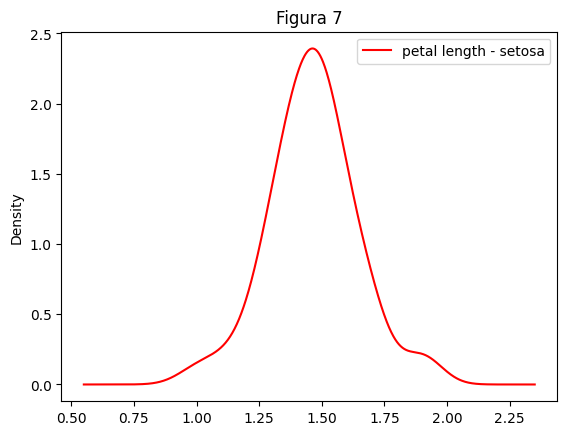

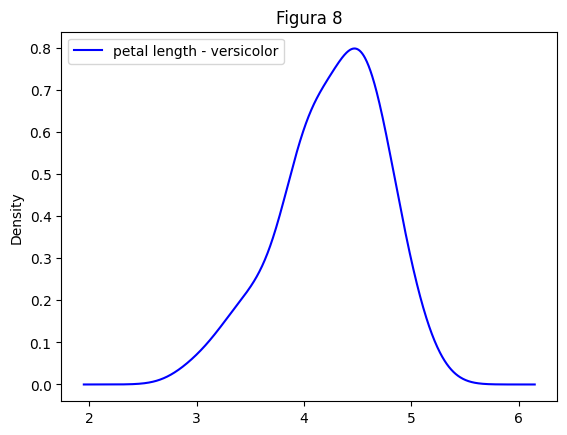

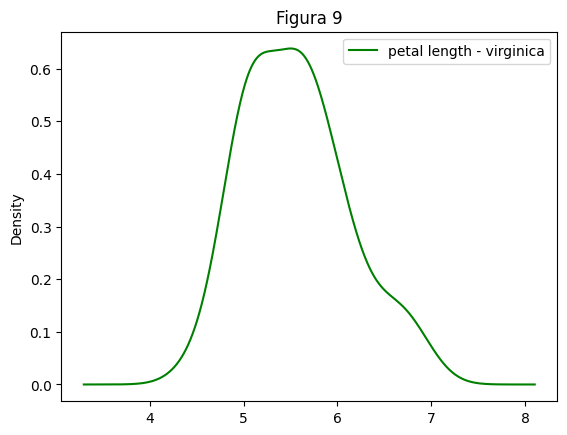

In [ ]:
dfpetlength_set.plot.kde(color='red', title='Figura 7')
dfpetlength_ver.plot.kde(color='blue', title='Figura 8')
dfpetlength_vir.plot.kde(color='green', title='Figura 9')

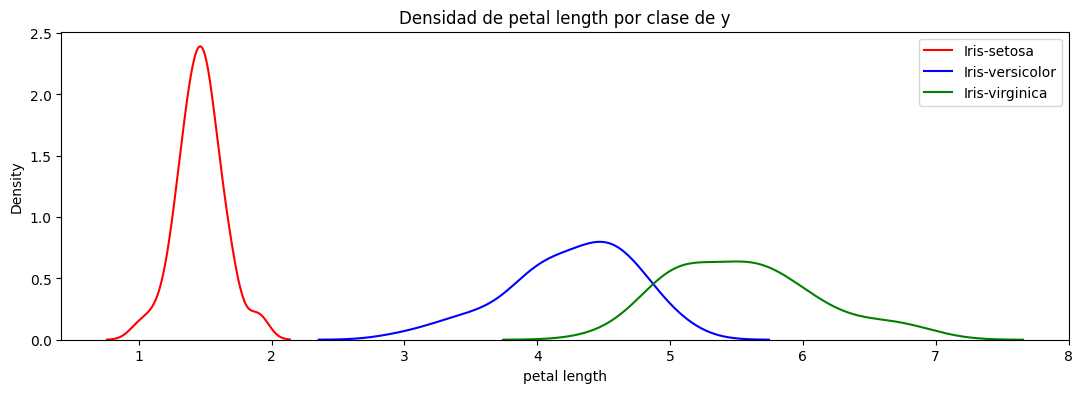

In [ ]:
# Visualización todas juntas

plt.figure(figsize=(13,4))
sns.kdeplot(petlength_set, color='red', label='Iris-setosa')
sns.kdeplot(petlength_ver, color='blue', label='Iris-versicolor')
sns.kdeplot(petlength_vir, color='green', label='Iris-virginica')
plt.title('Densidad de petal length por clase de y')
plt.legend()
plt.xlabel('petal length')
plt.show()

Si bien en los gráficos individuales podemos ver que presentan una distribución normal por las formas de las campanas de Gauss, pero cuando las combinamos para ver todas juntas, algunas se superponen y las varianzas internas de los subgrupos son muy grandes. Podriamos decir que capaz cumplan con la condición de normalidad pero habria que ver si cumplen con la homogeneidad de las varianzas

Ahora calculamos el estimador para tener más pruebas.


Condición de normalidad

In [ ]:
# NORMALIDAD petlength_set


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(petlength_set)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.955
p= 0.055
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD petlength_ver


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(petlength_ver)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.966
p= 0.158
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


In [ ]:
# NORMALIDAD petlength_vir


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(petlength_vir)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.962
p= 0.11
No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana


De los resultados para los tres subconjuntos de petal length (Iris setosa, Iris versicolor, Iris virginica) vemos que todos cumplirian con la condición de normalidad por los valores de probabilidad que están por encima del nivel de significancia. Aunque para el subconjunto de petal length - Iris setosa, vemos que la probabilidad es muy cerca o casi igual que 5%. No obstante, cumple con la condicion.

De esta manera, podriamos asumir que no es posible rechazar la H0 de que es Gaussiana.

Ahora calculamos las varianzas para ver la otra condición de ANOVA:

Condición de homogeneidad:

In [ ]:
# HOMOGENEIDAD DE LAS VARIANZAS
var_petlength_set=np.var(petlength_set)
var_petlength_ver=np.var(petlength_ver)
var_petlength_vir=np.var(petlength_vir)

max_var=np.max([var_petlength_set,var_petlength_ver,var_petlength_vir])     # Máximo de las varianzas de los subgrupos
min_var=np.min([var_petlength_set,var_petlength_ver,var_petlength_vir])     # Mínimo de las varianzas de los subgrupos

ratio_var_petal_length=max_var/min_var                  # Cálculo de ratio
print('ratio_var_x1= ', ratio_var_petal_length)

ratio_var_x1=  10.117129674114256


Bueno vemos que el ratio nos dio muy por fuera  de los márgenes aceptables, de no mayor a 2 (o en casos extremos no mayor a 4). Esto lo comprobamos también visualmente en los gráficos de las campanas, donde los anchos de las mismas eran muy amplios en algunas y en otra no

En consecuencia, la variable petal length no puede analizarse con ANOVA, por no cumplir con la condición de homogenieidad de las varianzas.

Sin embargo, esto no nos indica si hay o no relación con y, con lo cual, para ver eso recurrimos al MI (que lo hicimos al inicio).

*Variable petal width*

In [ ]:
petwidth_set = df['petal width'][df.y=='Iris-setosa']
dfpetwidth_set=pd.DataFrame(petwidth_set)
dfpetwidth_set.columns=['petal width - setosa']

petwidth_ver = df['petal width'][df.y=='Iris-versicolor']
dfpetwidth_ver=pd.DataFrame(petwidth_ver)
dfpetwidth_ver.columns=['petal width - versicolor']

petwidth_vir = df['petal width'][df.y=='Iris-virginica']
dfpetwidth_vir=pd.DataFrame(petwidth_vir)
dfpetwidth_vir.columns=['petal width - virginica']

<Axes: title={'center': 'Figura 12'}, ylabel='Density'>

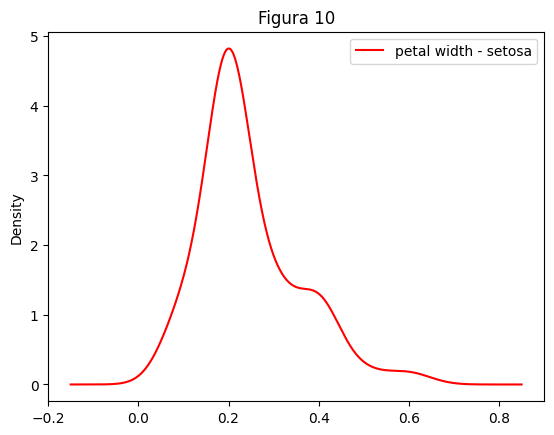

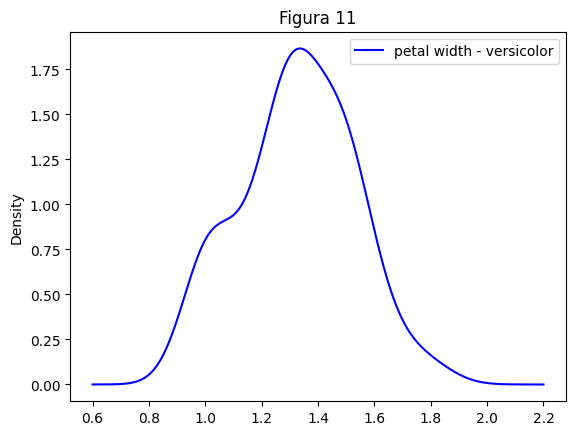

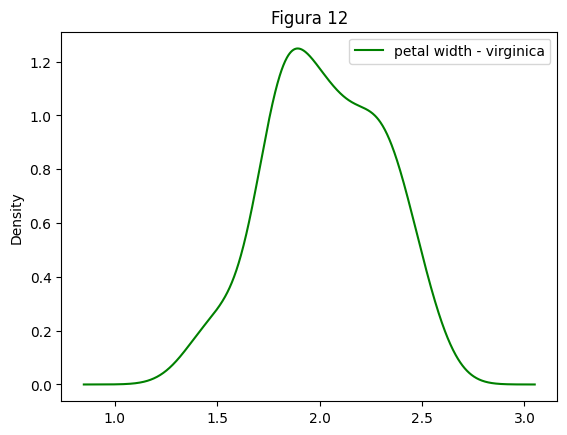

In [ ]:
dfpetwidth_set.plot.kde(color='red', title='Figura 10')
dfpetwidth_ver.plot.kde(color='blue', title='Figura 11')
dfpetwidth_vir.plot.kde(color='green', title='Figura 12')

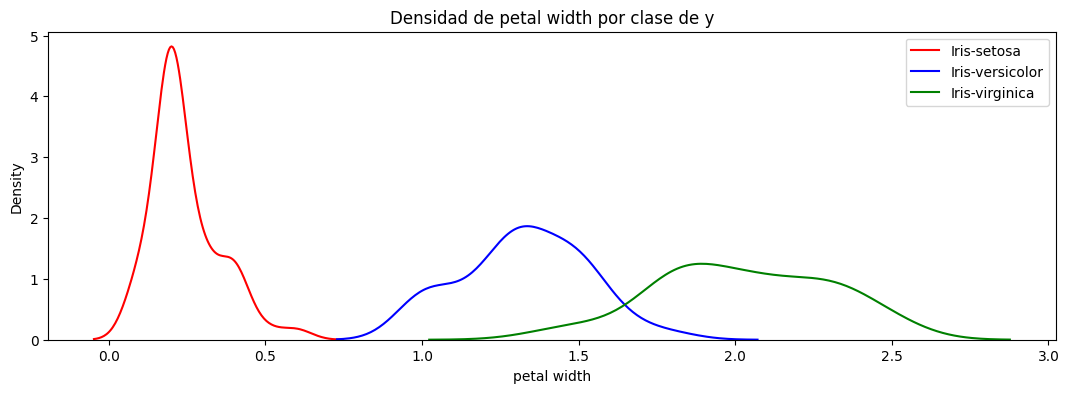

In [ ]:
# Visualización todas juntas

plt.figure(figsize=(13,4))
sns.kdeplot(petwidth_set, color='red', label='Iris-setosa')
sns.kdeplot(petwidth_ver, color='blue', label='Iris-versicolor')
sns.kdeplot(petwidth_vir, color='green', label='Iris-virginica')
plt.title('Densidad de petal width por clase de y')
plt.legend()
plt.xlabel('petal width')
plt.show()

Estos gráficos es un caso similar al de la variable petal length, donde el ancho de las campanas, cuando las visualizamos todas juntas, algunas se superponen y las varianzas internas de los subgrupos son muy diferentes. Las campanas de color azul y verde son bastantes más anchas que la campana roja.  

Podriamos decir que capaz cumplan con la condición de normalidad pero habria que ver si cumplen con la homogeneidad de las varianzas

Ahora calculamos el estimador para verificar lo de la normalidad.

Condición de normalidad

In [ ]:
# NORMALIDAD petwidth_set


alpha = 0.05                           # Nivel de significancia
W, p = shapiro(petwidth_set)                    # W es el predictor y p la probabilidad
print('W Shapiro-Wilk= ', round(W,3) )
print('p=', round(p,3))


if p > alpha:
    print('No es posible rechazar la Hipótesis (H0) de que es Gaussiana, así que asumiremos que es una distribución Gaussiana')
else:
    print('Se rechaza la Hipótesis de que es Gaussiana (H0)')

W Shapiro-Wilk=  0.814
p= 0.0
Se rechaza la Hipótesis de que es Gaussiana (H0)


Como vemos, se obtuvo una probabilidad de 0, con lo cual se rechaza la hipótesis de que tenga distribución normal (campana de Gauss).

Entonces decimos que no se cumple el requisito de normalidad para uno de los grupos ( petal width - Iris setona). En consecuencia, la variable petal width no puede analizarse con ANOVA, ya que, al no cumplirse en un subconjunto descartamos que se cumpla para el resto.

Sin embargo, esto no nos indica si hay o no relación con y, con lo cual, para ver eso recurrimos al MI (que lo hicimos al inicio).



**CONCLUSIÓN**

Si tomamos los resultados obtenidos por Información Mutua, vemos que tanto las variables petal length (largo del pétalo), petal width (ancho del pétalo) y  sepal length (largo del sépalo) tendrían relación con nuestra variable objetivo 'y' (tipo de flor). Con respecto a la variable sepal width (ancho del sépalo) se decidió que podría ser descartada por su bajo valor explicativo de y, en relación a las demás.

Ahora si tomamos el análisis que hicimos con ANOVA, obtuvimos que la variable sepal length SI tiene relación con y, lo cual coincide con lo que deducimos del MI.

Al ver las observaciones de la variable sepal width con ANOVA SI nos dió que tiene relación con el tipo de flor. A diferencia del análisis anterior donde decidimos descartarla por su bajo valor de MI en relación a las demás. Es por ello, que es importante aplicar ambos métodos, ya que nos sirven como complementos para determinar la relación entre las variables.
Con respecto a las variables petal length y petal width no se pudo aplicar ANOVA al no cumplir con los requisitos, con lo cual no obtuvimos información si hay relación o no.

Finalmente, podemos afirmar que ambos métodos nos sirven para determinar la existencia de las relaciones entre una variable continua y la variable target categórica. Y en este problema en particular se utilizaron ambos métodos para poder llegar a la conclusión que todas las variables son relevantes para explicar y.






